# Surrogate Generation for Signal Importance


This notebook generates surrogate time series of the estimated signal importance
by randomly shuffling the original time series.
The surrogates serve as a null distribution for the permutation test
performed in the subsequent R Markdown analysis.

- For reference, see: https://github.com/mlcs/iaaft

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl
import iaaft

## Data loading

In [4]:
dir = "../results/"
timevariable_coef = pd.read_csv(f"{dir}SignalImportance_average.csv", index_col=0) 
timevariable_coef.head()
Data1input = pd.read_csv("../data/20151001_20171015_env_inGSI.csv", index_col=0)
Data1output = pd.read_csv("../data/20151001_20171015_raw_GSIdata_ci.csv", index_col=0)

## Visualization of iaaft

Estim100%|██████████████████████████████| 100000/100000 [00:16<00:00, 6199.85it/s]


(100000, 48)


/var/folders/nh/xsx_6tbx0xg13fwlq2m_8yn40000gn/T/ipykernel_44324/3878044102.py:46: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "steelblue" (-> color=(0.27450980392156865, 0.5098039215686274, 0.7058823529411765, 1.0)). The keyword argument will take precedence.
  ax1.plot(Data1output["Time"][0:-1],x, "steelblue", label="$w_{WT}$", color=colo_)


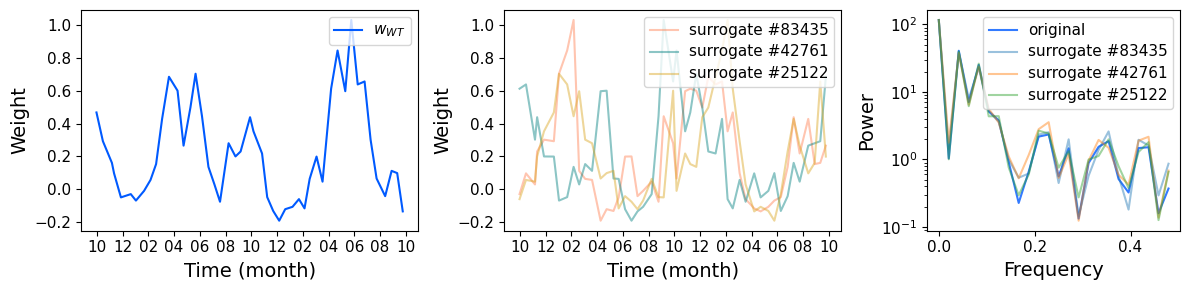

In [8]:
colors = ["#ff4b00", "#005aff","orange","#03af7a", "black"]
factor="WT"
colo_ = colors[1]

n = 100
beta = 0.65
eps = np.random.randn(n)
x = np.zeros(n)
x[0] = eps[0]
for i in range(1, n):
    x[i] = beta * x[i-1] + eps[i]

ns = 100000
def surogete(waveform):
    x = np.array(waveform)
    n = len(x)
    # estimate the power spectra of the initial time series
    
    p = np.square(np.abs(np.fft.fft(x)))
    freq = np.fft.fftfreq(n)
    
    # estimate ns=10 IAAFT surrogates
    xs = iaaft.surrogates(x=x, ns=ns, verbose=True)
    print(xs.shape)

    # estimate the power spectra of the surrogates
    ps = np.zeros((ns, freq.shape[0]))
    for i in range(ns):
        ps[i] = np.square(np.abs(np.fft.fft(xs[i])))
    return x, xs, p, freq, ps

data_load = False
if data_load:
    ns = 99999
    xs = np.array(pd.read_csv(f"{dir}random{factor}coef.csv", header=None))
else:
    x, xs, p, freq, ps = surogete(timevariable_coef['WT'])

AXLABFS, TIKLABFS = 14, 11
fig = pl.figure(figsize=[12., 3.])
gs = fig.add_gridspec(1, 3, width_ratios=[2, 2, 1.5])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

ax1.plot(Data1output["Time"][0:-1],x, "steelblue", label="$w_{WT}$", color=colo_)
ax1.set_xticks([6+60*i for i in range(13)]) 
ax1.set_xticklabels(["10", "12", "02", "04", "06", "08", "10", "12", "02", "04", "06", "08", "10"],fontsize=12)
    
idx = np.random.randint(ns, size=3)
clrs = ["coral", "teal", "goldenrod"]
for j, i in enumerate(idx):
    ax2.plot(Data1output["Time"][0:-1], xs[i], c=clrs[j], label="surrogate #%d" % i, alpha=0.45)
ax2.set_xticks([6+60*i for i in range(13)]) 
ax2.set_xticklabels(["10", "12", "02", "04", "06", "08", "10", "12", "02", "04", "06", "08", "10"],fontsize=12)

# plot the power spectra
k = np.argsort(freq)
k = k[int(len(k)/2):]
ax3.plot(freq[k], p[k], "-", mec="steelblue", mfc="none", label="original", alpha=0.8, color=colo_)
for j, i in enumerate(idx):
    ax3.plot(freq[k], ps[i, k], "-", mec=clrs[j], mfc="none", label="surrogate #%d" % i, alpha=0.45)
ax3.set_yscale("log")

# beautification
for ax in fig.axes:
    leg = ax.legend(loc="upper right")
    for txt in leg.get_texts():
        txt.set_size(TIKLABFS)
    ax.tick_params(labelsize=TIKLABFS)
for ax in [ax1, ax2]:
    ax.set_ylabel("Weight", fontsize=AXLABFS)
    ax.set_xlabel("Time (month)", fontsize=AXLABFS)
ax3.set_xlabel("Frequency", fontsize=AXLABFS)
ax3.set_ylabel("Power", fontsize=AXLABFS)

pl.tight_layout()
pl.show()

#fig.savefig(f"{dir}random{factor}coef.pdf")
#np.savetxt(f"{dir}randomized_{factor}imp.csv",xs,delimiter=',')

## Randomize signal importance and export

In [9]:
def save_if_not_exists(path: str, data: np.ndarray) -> None:
    """Save array to CSV only if the file does not already exist."""
    if not os.path.exists(path):
        np.savetxt(path, data, delimiter=",")
        print(f"Saved: {path}")
    else:
        print(f"Already exists, skipped: {path}")


# Generate surrogates and save for each signal
x, xs, p, freq, ps = surogete(timevariable_coef["WT"])
save_if_not_exists(f"{dir}andomized_WTimp.csv", xs)

x, xs, p, freq, ps = surogete(timevariable_coef["SR"])
save_if_not_exists(f"{dir}randomized_SRimp.csv", xs)

x, xs, p, freq, ps = surogete(timevariable_coef["GSI"])
save_if_not_exists(f"{dir}randomized_GSIimp.csv", xs)

x, xs, p, freq, ps = surogete(timevariable_coef["DL"])
save_if_not_exists(f"{dir}randomized_DLimp.csv", xs)

Estim100%|██████████████████████████████| 100000/100000 [00:19<00:00, 5180.44it/s]


(100000, 48)
Already exists, skipped: ./TV0603_alpha0win3noisemean/randomized_SRimp.csv


Estim100%|██████████████████████████████| 100000/100000 [00:14<00:00, 7017.98it/s]


(100000, 48)
Already exists, skipped: ./TV0603_alpha0win3noisemean/randomized_GSIimp.csv


Estim100%|██████████████████████████████| 100000/100000 [00:18<00:00, 5286.46it/s]


(100000, 48)
Already exists, skipped: ./TV0603_alpha0win3noisemean/randomized_DLimp.csv


### Subsequent Analysis:

 **Comparison with gene expression profiles**
   → [`comparison_geneexpression.Rmd`](./Medaka_RNAseq_analysis.Rmd)

In [7]:
import subprocess
import os

rmd_path = os.path.abspath("../rnaseq_analysis/Medaka_RNAseq_analysis.Rmd")

# Open the R Markdown file in RStudio (if available), otherwise fall back to the system default
try:
    # macOS
    subprocess.Popen(["open", "-a", "RStudio", rmd_path])
except FileNotFoundError:
    try:
        # Linux (RStudio installed)
        subprocess.Popen(["rstudio", rmd_path])
    except FileNotFoundError:
        # Windows
        subprocess.Popen(["cmd", "/c", "start", rmd_path])

print(f"Opening: {rmd_path}")

Opening: /Users/itoutouma/Research/InverseSignalImportance_share/rnaseq_analysis/Medaka_RNAseq_analysis.Rmd
